# 03. Modeling: Predicting Gaming Addiction Risk Level

This notebook focuses on building and evaluating machine learning models to predict the gaming addiction risk level of a person. The target variable contains four classes: Low, Moderate, High, and Severe. To solve this classification problem, multiple models and feature selection strategies are compared, including Logistic Regression, Random Forest, SelectKBest, and Recursive Feature Elimination with Cross-Validation (RFECV). The goal is to identify the model that provides the strongest predictive performance while also maintaining a clear and justifiable modeling process.

# Dataset Overview

In the previous notebook 02_preprocessing_and_feature we have already looked over the data and cleaned it from any null values and selected features that are appropriate for our Domain. Here we are displaying again the dataset for easier visualization.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.base import clone

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

DATA_PATH = Path("../data/processed/gaming_option_a_processed.csv")
df = pd.read_csv(DATA_PATH)

df.head()

,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,exercise_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,3.7,383.70,3,Severe
1,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,8.5,46.64,1,Low
2,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,7.1,100.81,6,Severe
3,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,5.2,51.60,7,High
4,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,6.1,32.57,1,Moderate


# Target Distribution and Evaluation Metric

The target variable is not perfectly balanced, which means that evaluation cannot rely only on accuracy. If one class appears much more often than the others, a model could achieve a deceptively high accuracy by predicting the majority class more often. For this reason, macro F1-score is used as the main evaluation metric. Macro F1 gives equal importance to each class and is therefore more appropriate for this multi-class imbalanced classification problem.

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nTarget distribution:")
print(df["gaming_addiction_risk_level"].value_counts())

Shape: (1000, 13)

Columns:
['age', 'gender', 'daily_gaming_hours', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'exercise_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gaming_addiction_risk_level']

Missing values:
age                            0
gender                         0
daily_gaming_hours             0
game_genre                     0
primary_game                   0
gaming_platform                0
sleep_hours                    0
sleep_quality                  0
sleep_disruption_frequency     0
exercise_hours_weekly          0
monthly_game_spending_usd      0
years_gaming                   0
gaming_addiction_risk_level    0
dtype: int64

Target distribution:
gaming_addiction_risk_level
Low         514
Moderate    190
High        154
Severe      142
Name: count, dtype: int64


In [3]:
target = "gaming_addiction_risk_level"

X = df.drop(columns=[target])
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 12)
y shape: (1000,)


In [4]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['High' 'Low' 'Moderate' 'Severe']


In [5]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['age', 'daily_gaming_hours', 'sleep_hours', 'exercise_hours_weekly', 'monthly_game_spending_usd', 'years_gaming']

Categorical columns:
['gender', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_quality', 'sleep_disruption_frequency']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 12)
X_test: (200, 12)
y_train: (800,)
y_test: (200,)


# Preprocessing Strategy

To prepare the dataset for modeling, the features are separated into numerical and categorical groups and transformed using a preprocessing pipeline. Numerical features are handled differently from categorical features so that each data type is processed appropriately. This pipeline-based approach ensures that preprocessing is applied consistently during both training and testing, which reduces the risk of data leakage and makes the workflow easier to reproduce.

In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Baseline Model 1: Logistic Regression

Logistic Regression is used as the first baseline model because it is a simple and interpretable linear classifier. Although it may not capture complex non-linear relationships as effectively as tree-based models, it provides a useful reference point for evaluating whether more advanced models offer meaningful improvements.

In [8]:
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg, average="macro")

print("Logistic Regression Accuracy:", round(logreg_accuracy, 4))
print("Logistic Regression Macro F1:", round(logreg_f1, 4))
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_logreg, target_names=label_encoder.classes_))

Logistic Regression Accuracy: 0.67
Logistic Regression Macro F1: 0.5474

Logistic Regression Classification Report:

              precision    recall  f1-score   support

        High       0.36      0.26      0.30        31
         Low       0.86      0.91      0.89       103
    Moderate       0.36      0.42      0.39        38
      Severe       0.67      0.57      0.62        28

    accuracy                           0.67       200
   macro avg       0.56      0.54      0.55       200
weighted avg       0.66      0.67      0.66       200



d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The Logistic Regression model provides a useful baseline, but its performance is limited compared with more flexible models. Because this is a multi-class problem with potentially non-linear patterns, it is reasonable to expect that a tree-based approach may perform better.

A convergence warning was also produced during training. This means the optimization process did not fully converge within the default number of iterations. While the model still returns predictions, this warning suggests that the result may be improved by increasing the maximum number of iterations, scaling numerical features more carefully, or adjusting solver settings.

# Baseline Model 2: Random Forest

Random Forest is used as the second baseline model because it can capture non-linear relationships and interactions between features more effectively than a linear model. It is also robust to noise and often performs well on structured tabular data. This makes it a strong candidate for this prediction task.

In [9]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Random Forest Macro F1:", round(rf_f1, 4))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Accuracy: 0.695
Random Forest Macro F1: 0.5957

Random Forest Classification Report:

              precision    recall  f1-score   support

        High       0.41      0.35      0.38        31
         Low       0.86      0.90      0.88       103
    Moderate       0.39      0.39      0.39        38
      Severe       0.74      0.71      0.73        28

    accuracy                           0.69       200
   macro avg       0.60      0.59      0.60       200
weighted avg       0.69      0.69      0.69       200



The Random Forest model performs better than Logistic Regression, which suggests that the relationship between the input variables and addiction risk level is not purely linear. This result supports the use of tree-based methods for the remainder of the modeling process.

# Baseline Comparison

To compare the two baseline models fairly, both accuracy and macro F1-score are examined. Accuracy gives a general indication of overall prediction success, while macro F1-score gives a more balanced view across all classes. Since the class distribution is imbalanced, macro F1-score is used as the main criterion for deciding which baseline model is stronger.

In [10]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logreg_accuracy, rf_accuracy],
    "Macro F1": [logreg_f1, rf_f1]
})

results.sort_values(by="Macro F1", ascending=False)

,Model,Accuracy,Macro F1
1,Random Forest,0.695,0.595709
0,Logistic Regression,0.670,0.547402


The baseline comparison shows that Random Forest outperforms Logistic Regression on the classification task. This indicates that a more flexible model is better able to capture the underlying patterns in the dataset. Based on this result, Random Forest is the more promising foundation for additional optimization and feature selection experiments.

## Feature Selection with SelectKBest

Feature selection is tested to examine whether reducing the number of input variables can improve performance or simplify the model. SelectKBest is used as a filter-based feature selection technique that keeps only the top-ranked features according to a statistical scoring method. This experiment helps determine whether all transformed features are necessary for good predictive performance.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [12]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

baseline_scores = cross_val_score(
    baseline_model,
    X,
    y_encoded,
    cv=cv,
    scoring="f1_macro"
)

print("Baseline Macro F1 scores:", baseline_scores)
print("Baseline Mean Macro F1:", round(baseline_scores.mean(), 4))
print("Baseline Std Macro F1:", round(baseline_scores.std(), 4))

Baseline Macro F1 scores: [0.61212479 0.56390555 0.57276558 0.56967678 0.53138849]
Baseline Mean Macro F1: 0.57
Baseline Std Macro F1: 0.0257


In [13]:
results_kbest = []

for k in [5, 10, 15, 20, 25]:
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("selector", SelectKBest(score_func=mutual_info_classif, k=k)),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ])

    scores = cross_val_score(
        model,
        X,
        y_encoded,
        cv=cv,
        scoring="f1_macro"
    )

    results_kbest.append({
        "k": k,
        "mean_macro_f1": scores.mean(),
        "std_macro_f1": scores.std()
    })

results_kbest_df = pd.DataFrame(results_kbest).sort_values(
    by="mean_macro_f1",
    ascending=False
)

results_kbest_df

d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values b

,k,mean_macro_f1,std_macro_f1
0,5,0.611436,0.036800
4,25,0.604570,0.045446
1,10,0.589517,0.053131
2,15,0.588220,0.064113
3,20,0.586738,0.054454


In [14]:
best_k = int(results_kbest_df.iloc[0]["k"])
print("Best k:", best_k)

Best k: 5


In [15]:
best_kbest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=best_k)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

best_kbest_model.fit(X, y_encoded)

d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values b

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [16]:
feature_names = best_kbest_model.named_steps["preprocessor"].get_feature_names_out()
selected_mask = best_kbest_model.named_steps["selector"].get_support()
selected_features = feature_names[selected_mask]

print("Selected transformed features:")
for feature in selected_features:
    print(feature)

Selected transformed features:
num__daily_gaming_hours
num__sleep_hours
num__exercise_hours_weekly
num__monthly_game_spending_usd
cat__sleep_quality_Good


In [30]:
selected_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=best_k)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

selected_scores = cross_val_score(
    selected_model,
    X,
    y_encoded,
    cv=cv,
    scoring="f1_macro"
)

comparison_df = pd.DataFrame({
    "Model": ["Baseline RF (all transformed features)", f"RF + SelectKBest (k={best_k})"],
    "Mean Macro F1": [baseline_scores.mean(), selected_scores.mean()],
    "Std Macro F1": [baseline_scores.std(), selected_scores.std()]
}).sort_values(by="Mean Macro F1", ascending=False)

comparison_df

d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
d:\Fontys\Semester 4 - ML\Practice Challenge\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values b

,Model,Mean Macro F1,Std Macro F1
1,RF + SelectKBest (k=5),0.611436,0.03680
0,Baseline RF (all transformed features),0.569972,0.02573


The SelectKBest results show whether limiting the model to the strongest features improves generalization. Even when performance improves only slightly, feature selection can still be valuable because it reduces model complexity and makes the final feature set easier to interpret.

# Recursive Feature Elimination with Cross-Validation (RFECV)

RFECV is used as a more advanced feature selection method. Unlike SelectKBest, which ranks features independently, RFECV recursively removes features based on model performance and uses cross-validation to determine the optimal number of features. This makes it a stronger method for identifying a compact subset of features that still preserves predictive power.

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

# 1. Baseline Random Forest
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

# 2. Random Forest + RFECV
rfecv_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", RFECV(
        estimator=RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),
        step=1,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rfecv_model.fit(X_train, y_train)
rfecv_preds = rfecv_model.predict(X_test)

# 3. Compare properly
comparison = pd.DataFrame([
    {
        "Model": "Baseline Random Forest",
        "Accuracy": accuracy_score(y_test, baseline_preds),
        "Macro F1": f1_score(y_test, baseline_preds, average="macro")
    },
    {
        "Model": "Random Forest + RFECV",
        "Accuracy": accuracy_score(y_test, rfecv_preds),
        "Macro F1": f1_score(y_test, rfecv_preds, average="macro")
    }
])

comparison = comparison.sort_values("Macro F1", ascending=False).reset_index(drop=True)

print("Model comparison:")
print(comparison)

# 4. Show selected features
feature_names = rfecv_model.named_steps["preprocessor"].get_feature_names_out()
selected_mask = rfecv_model.named_steps["selector"].support_
selected_features = feature_names[selected_mask]

print("\nRFECV selected features:", len(selected_features))
print("Selected feature names:")
for feature in selected_features:
    print("-", feature)


Model comparison:
                    Model  Accuracy  Macro F1
0   Random Forest + RFECV     0.730  0.648798
1  Baseline Random Forest     0.695  0.595709

RFECV selected features: 5
Selected feature names:
- num__age
- num__daily_gaming_hours
- num__sleep_hours
- num__exercise_hours_weekly
- num__monthly_game_spending_usd


The RFECV-based Random Forest achieved the strongest performance among the tested approaches, with an accuracy of 0.73 and a macro F1-score of 0.6488. This suggests that reducing the feature space in a model-informed way helped the classifier focus on the most useful predictors while improving generalization. RFECV selected 5 features, which also makes the final model simpler and easier to interpret than a model using the full transformed feature set.

Adding class balancing was tested to address the moderate class imbalance in the target variable. However, the weighted Random Forest produced slightly lower accuracy and macro F1 than the unweighted version. This indicates that class imbalance was not the main limitation of the model. The best-performing model remained the RFECV-based Random Forest without class weighting.

# 

# Confusion Matrix

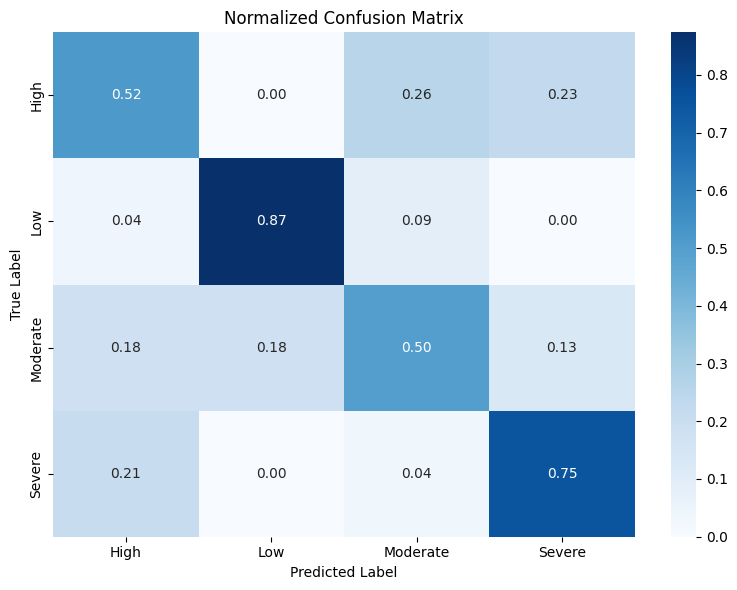

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(
    y_test,
    rfecv_preds,
    labels=np.arange(len(label_encoder.classes_))
)

cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# RFECV WITH CLASS BALANCE


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

balanced_rfecv_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", RFECV(
        estimator=RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        step=1,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

balanced_rfecv_model.fit(X_train, y_train)
balanced_rfecv_preds = balanced_rfecv_model.predict(X_test)

print("Balanced Random Forest + RFECV")
print("Accuracy:", accuracy_score(y_test, balanced_rfecv_preds))
print("Macro F1:", f1_score(y_test, balanced_rfecv_preds, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, balanced_rfecv_preds))

feature_names = balanced_rfecv_model.named_steps["preprocessor"].get_feature_names_out()
selected_mask = balanced_rfecv_model.named_steps["selector"].support_
selected_features = feature_names[selected_mask]

print("\nRFECV selected features:", len(selected_features))
print("Selected feature names:")
for feature in selected_features:
    print("-", feature)

Balanced Random Forest + RFECV
Accuracy: 0.72
Macro F1: 0.6359226982205317

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.45      0.45        31
           1       0.95      0.86      0.90       103
           2       0.48      0.53      0.50        38
           3       0.64      0.75      0.69        28

    accuracy                           0.72       200
   macro avg       0.63      0.65      0.64       200
weighted avg       0.74      0.72      0.73       200


RFECV selected features: 5
Selected feature names:
- num__age
- num__daily_gaming_hours
- num__sleep_hours
- num__exercise_hours_weekly
- num__monthly_game_spending_usd


# SMOTENC + Random Forest

In [28]:
from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy import sparse
import numpy as np
import pandas as pd

# 1. Get categorical column indices from original training data
categorical_feature_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

print("Categorical columns:", categorical_cols)
print("Categorical feature indices:", categorical_feature_indices)

# 2. Apply SMOTENC on ORIGINAL training data only
smotenc = SMOTENC(
    categorical_features=categorical_feature_indices,
    random_state=42
)

X_train_resampled, y_train_resampled = smotenc.fit_resample(X_train, y_train)

print("Original training shape:", X_train.shape, y_train.shape)
print("Resampled training shape:", X_train_resampled.shape, y_train_resampled.shape)

# 3. Preprocess after resampling
X_train_resampled_processed = preprocessor.fit_transform(X_train_resampled)
X_test_processed = preprocessor.transform(X_test)

# 4. Convert sparse matrices if needed
if sparse.issparse(X_train_resampled_processed):
    X_train_resampled_processed = X_train_resampled_processed.toarray()
if sparse.issparse(X_test_processed):
    X_test_processed = X_test_processed.toarray()

# 5. Train Random Forest
smotenc_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

smotenc_rf_model.fit(X_train_resampled_processed, y_train_resampled)

# 6. Predict on untouched test set
smotenc_rf_preds = smotenc_rf_model.predict(X_test_processed)

# 7. Evaluate
print("\nSMOTENC + Random Forest")
print("Accuracy:", accuracy_score(y_test, smotenc_rf_preds))
print("Macro F1:", f1_score(y_test, smotenc_rf_preds, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, smotenc_rf_preds))

Categorical columns: ['gender', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_quality', 'sleep_disruption_frequency']
Categorical feature indices: [1, 3, 4, 5, 7, 8]
Original training shape: (800, 12) (800,)
Resampled training shape: (1644, 12) (1644,)

SMOTENC + Random Forest
Accuracy: 0.74
Macro F1: 0.6649402833663725

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.32      0.42        31
           1       0.96      0.84      0.90       103
           2       0.46      0.76      0.57        38
           3       0.76      0.79      0.77        28

    accuracy                           0.74       200
   macro avg       0.69      0.68      0.66       200
weighted avg       0.78      0.74      0.74       200



SMOTENC was tested to address class imbalance while preserving categorical feature structure. It achieved similar accuracy to the Random Forest + RFECV and its macro F1-score and even managed to surpass it by just a little bit. This suggests that synthetic oversampling is not always the best way to substantially improve a model’s ability to separate all classes, however this time it managed to help. Therefore, the SMOTENC Random Forest is currently the model with the best Accuracy and F1 Score.

# Final Model Comparison

To select the final model, all major experiments are compared in one summary table. This includes the baseline models and the feature selection variants. The comparison focuses on identifying the model that provides the best balance between predictive performance and model simplicity.

In [29]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

logreg_preds = logreg_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
rfecv_preds = rfecv_model.predict(X_test)
balanced_rfecv_preds = balanced_rfecv_model.predict(X_test)
smotenc_rf_preds = smotenc_rf_model.predict(X_test_processed)

final_comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, logreg_preds),
        "Macro F1": f1_score(y_test, logreg_preds, average="macro")
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_preds),
        "Macro F1": f1_score(y_test, rf_preds, average="macro")
    },
    {
        "Model": "Random Forest + RFECV",
        "Accuracy": accuracy_score(y_test, rfecv_preds),
        "Macro F1": f1_score(y_test, rfecv_preds, average="macro")
    },
    {
        "Model": "Random Forest + RFECT + Balanced",
        "Accuracy": accuracy_score(y_test, balanced_rfecv_preds),
        "Macro F1": f1_score(y_test, balanced_rfecv_preds, average="macro")
    },
    {
        "Model": "SMOTENC + Random Forest",
        "Accuracy": accuracy_score(y_test, smotenc_rf_preds),
        "Macro F1": f1_score(y_test, smotenc_rf_preds, average="macro")
    }
    
])

final_comparison_df = final_comparison_df.sort_values("Macro F1", ascending=False).reset_index(drop=True)

final_comparison_df

,Model,Accuracy,Macro F1
0,SMOTENC + Random Forest,0.740,0.664940
1,Random Forest + RFECV,0.730,0.648798
2,Random Forest + RFECT + Balanced,0.720,0.635923
3,Random Forest,0.695,0.595709
4,Logistic Regression,0.670,0.547402


The final comparison confirms that SMOTENC + Random Forest V is the best-performing approach in this notebook, even better than the balanced Random Forest with RFECV. It achieved the highest macro F1-score. This makes it the most suitable final model for predicting gaming addiction risk level in the current dataset.

# Conclusion

Among the tested models, SMOTENC + Random Forest achieved the best final performance, with an accuracy of 0.74 and a macro F1-score of 0.6649. This means it provided the best overall balance between correct predictions and fairer performance across the different classes. The results also suggest that moderate class imbalance had some impact, since SMOTENC slightly improved the final outcome compared with the other Random Forest variants. At the same time, the differences between the strongest models were relatively small, which shows that the dataset remains challenging and that some classes are naturally harder to separate than others. Overall, SMOTENC + Random Forest is the most suitable final model for the current dataset because it produced the strongest combination of accuracy and macro F1-score among all evaluated approaches.